In [ ]:
# Install dependencies (run once in Colab or a fresh environment)
!pip install torch torchvision torchaudio --quiet
!pip install git+https://github.com/RobustBench/robustbench.git --quiet
!pip install git+https://github.com/fra31/auto-attack --quiet
!pip install matplotlib scikit-learn --quiet


##  Imports & Setup

All global constants and library imports live here.
The binary subset is fixed to **Cat (class 3)** and **Dog (class 5)**.


In [18]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from robustbench import load_model
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# CIFAR-10 class names
CLASSES = ["airplane","automobile","bird","cat","deer",
           "dog","frog","horse","ship","truck"]

CAT_IDX = 3
DOG_IDX = 5
BINARY_CLASSES = {CAT_IDX: "cat", DOG_IDX: "dog"}

# L-inf threat-model budget (8/255 is the standard CIFAR-10 benchmark)
EPSILON = 8 / 255

print(f"Binary subset: {CAT_IDX}=cat  {DOG_IDX}=dog  epsilon={EPSILON:.5f}")

Device: cuda
Binary subset: 3=cat  5=dog  epsilon=0.03137


##   Model Loading

**Model A** — `Standard` (no adversarial training, high clean accuracy, low robustness).

**Model B** — `Engstrom2019Robustness` (L-inf adversarially trained, lower clean accuracy, high robustness).



In [19]:
model_a = load_model(model_name="Standard",
                     dataset="cifar10",
                     threat_model="Linf").to(device)

model_b = load_model(model_name="Engstrom2019Robustness",
                     dataset="cifar10",
                     threat_model="Linf").to(device)

model_a.eval()
model_b.eval()

print("Model A:", type(model_a).__name__)
print("Model B:", type(model_b).__name__)

Model A: WideResNet
Model B: Engstrom2019RobustnessNet


## Data Loading : Cat / Dog Filter

**Loading strategy:**
1. If the pre-saved `.pt` perturbation files are present, load and mask them to keep only Cat/Dog rows.
2. If the masked subset has fewer than `MIN_PT_SAMPLES` rows, fall back to sampling Cat/Dog images directly from the CIFAR-10 test set.


In [20]:
NUM_SAMPLES    = 16   # number of Cat/Dog images to analyse
MIN_PT_SAMPLES = 4    # minimum rows required from a .pt file

PT_FILES = {
    "standard": "/content/cifar10_standard_linf_eps8_adv.pt",
    "engstrom":  "/content/cifar10_engstrom_linf_eps8_adv.pt",
}


def load_and_mask_pt(path):
    """Load a saved .pt dict and return only the Cat/Dog rows.

    Returns (clean_images, clean_labels, adv_images, perturbations)
    or None if the file is absent or too few Cat/Dog samples exist.
    """
    if not os.path.isfile(path):
        print(f"  {os.path.basename(path)}: not found, skipping.")
        return None
    data   = torch.load(path, map_location="cpu", weights_only=False)
    labels = data["clean_labels"]
    mask   = (labels == CAT_IDX) | (labels == DOG_IDX)
    n      = mask.sum().item()
    print(f"  {os.path.basename(path)}: {n} cat/dog rows out of {len(labels)}")
    if n < MIN_PT_SAMPLES:
        print(f"  Too few rows ({n} < {MIN_PT_SAMPLES}), will fall back.")
        return None
    return (data["clean_images"][mask],
            data["clean_labels"][mask],
            data["adv_images"][mask],
            data["perturbations"][mask])


def build_catdog_dataset(n=NUM_SAMPLES):
    """Sample n Cat and Dog images from the CIFAR-10 test set."""
    ds         = datasets.CIFAR10(root="./data", train=False,
                                   download=True, transform=transforms.ToTensor())
    indices    = [i for i, (_, lbl) in enumerate(ds)
                  if lbl in (CAT_IDX, DOG_IDX)]
    np.random.seed(42)
    chosen     = np.random.choice(indices, size=min(n, len(indices)), replace=False)
    loader     = DataLoader(Subset(ds, chosen),
                            batch_size=len(chosen), shuffle=False)
    imgs, lbls = next(iter(loader))
    return imgs, lbls


print("Checking .pt files for Cat/Dog samples ...")
pt_std = load_and_mask_pt(PT_FILES["standard"])
pt_eng = load_and_mask_pt(PT_FILES["engstrom"])

if pt_std is not None:
    clean_images = pt_std[0].to(device)
    clean_labels = pt_std[1].to(device)
    print(f"\nUsing pre-saved batch: {len(clean_labels)} images")
else:
    print("\nFalling back to live CIFAR-10 sampling ...")
    ci, cl       = build_catdog_dataset(NUM_SAMPLES)
    clean_images = ci.to(device)
    clean_labels = cl.to(device)
    print(f"Sampled {len(clean_labels)} Cat/Dog images from test set.")

print("clean_images:", clean_images.shape)
print("clean_labels:", clean_labels.tolist())
print("Label names: ", [BINARY_CLASSES[l.item()] for l in clean_labels])

Checking .pt files for Cat/Dog samples ...
  cifar10_standard_linf_eps8_adv.pt: not found, skipping.
  cifar10_engstrom_linf_eps8_adv.pt: not found, skipping.

Falling back to live CIFAR-10 sampling ...
Sampled 16 Cat/Dog images from test set.
clean_images: torch.Size([16, 3, 32, 32])
clean_labels: [5, 3, 5, 3, 3, 5, 3, 3, 3, 5, 3, 3, 3, 5, 3, 3]
Label names:  ['dog', 'cat', 'dog', 'cat', 'cat', 'dog', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat']


##   Baseline Clean Accuracy on Cat / Dog


In [21]:
with torch.no_grad():
    out_a = model_a(clean_images)
    out_b = model_b(clean_images)

pred_a = out_a.argmax(dim=1)
pred_b = out_b.argmax(dim=1)

acc_a = (pred_a == clean_labels).float().mean().item()
acc_b = (pred_b == clean_labels).float().mean().item()

print(f"Model A clean accuracy (cat/dog only): {acc_a:.1%}")
print(f"Model B clean accuracy (cat/dog only): {acc_b:.1%}")
print()
print(f"{'Img':<5} {'True':<6} {'Pred A':<12} {'Pred B':<12}")
print("-" * 37)
for i in range(len(clean_labels)):
    t  = CLASSES[clean_labels[i].item()]
    pa = CLASSES[pred_a[i].item()]
    pb = CLASSES[pred_b[i].item()]
    print(f"{i:<5} {t:<6} {'ok ' if pa==t else 'WRONG '}{pa:<6} "
          f"{'ok ' if pb==t else 'WRONG '}{pb:<6}")

Model A clean accuracy (cat/dog only): 93.8%
Model B clean accuracy (cat/dog only): 81.2%

Img   True   Pred A       Pred B      
-------------------------------------
0     dog    ok dog    ok dog   
1     cat    ok cat    ok cat   
2     dog    ok dog    ok dog   
3     cat    ok cat    ok cat   
4     cat    ok cat    ok cat   
5     dog    ok dog    ok dog   
6     cat    ok cat    ok cat   
7     cat    ok cat    ok cat   
8     cat    ok cat    ok cat   
9     dog    ok dog    ok dog   
10    cat    ok cat    ok cat   
11    cat    ok cat    WRONG deer  
12    cat    ok cat    WRONG dog   
13    dog    ok dog    ok dog   
14    cat    WRONG truck  WRONG truck 
15    cat    ok cat    ok cat   


##   GAAS Core Functions : Binary Cat/Dog Subspace

Both functions apply iterative Gram-Schmidt orthogonalisation to build a basis of independent adversarial directions:

- **L-inf GAAS** — step: `delta = eps * sign(g)`
- **L2 GAAS** — step: `delta = eps * g / ||g||_2`

Each function takes a single `(C, H, W)` image tensor and returns a list of direction tensors of the same shape.


In [ ]:
def gaas_directions_linf(model, x, y, epsilon=EPSILON, max_dirs=50):
    """Return orthogonal L-inf adversarial directions for a single input."""
    model.eval()
    x = x.clone().detach().unsqueeze(0).to(device)
    y = y.clone().detach().unsqueeze(0).to(device)
    directions = []

    for _ in range(max_dirs):
        x.requires_grad_(True)
        loss = F.cross_entropy(model(x), y)
        model.zero_grad()
        loss.backward()

        g = x.grad.detach().view(-1)

        # Gram-Schmidt: remove components of already-found directions
        for d in directions:
            d_f = d.view(-1)
            g   = g - (torch.dot(g, d_f) / (d_f.dot(d_f) + 1e-8)) * d_f

        if torch.norm(g) < 1e-10:
            break

        g     = g.view_as(x)
        delta = epsilon * torch.sign(g)   # L-inf step

        if model(x + delta).argmax(1).item() != y.item():
            directions.append(delta.detach())
        else:
            break

    return directions


def gaas_directions_l2(model, x, y, epsilon=EPSILON, max_dirs=50):
    """Return orthogonal L2 adversarial directions for a single input."""
    model.eval()
    x = x.clone().detach().unsqueeze(0).to(device)
    y = y.clone().detach().unsqueeze(0).to(device)
    directions = []

    for _ in range(max_dirs):
        x.requires_grad_(True)
        loss = F.cross_entropy(model(x), y)
        model.zero_grad()
        loss.backward()

        g      = x.grad.detach().view(-1)

        for d in directions:
            d_f = d.view(-1)
            g   = g - (torch.dot(g, d_f) / (d_f.dot(d_f) + 1e-8)) * d_f

        g_norm = torch.norm(g)
        if g_norm < 1e-10:
            break

        g     = g.view_as(x)
        delta = epsilon * g / g_norm      # L2 normalised step

        if model(x + delta).argmax(1).item() != y.item():
            directions.append(delta.detach())
        else:
            break

    return directions


print("GAAS direction functions defined (L-inf and L2).")

GAAS direction functions defined (L-inf and L2).


##  Adversarial Subspace Dimensionality

For each Cat/Dog image, count the number of orthogonal adversarial directions under both norms and both models.

Higher dimension means more independent ways to fool the classifier, which correlates with lower geometric robustness.


In [23]:
n       = len(clean_labels)
results = []

print(f"{'Img':<5} {'Class':<6} {'A Linf':<8} {'A L2':<8} {'B Linf':<8} {'B L2':<8}")
print("-" * 43)

for i in range(n):
    xi, yi = clean_images[i], clean_labels[i]
    cls    = BINARY_CLASSES.get(yi.item(), CLASSES[yi.item()])

    da_inf = len(gaas_directions_linf(model_a, xi, yi, max_dirs=50))
    da_l2  = len(gaas_directions_l2  (model_a, xi, yi, max_dirs=50))
    db_inf = len(gaas_directions_linf(model_b, xi, yi, max_dirs=50))
    db_l2  = len(gaas_directions_l2  (model_b, xi, yi, max_dirs=50))

    results.append(dict(idx=i, cls=cls, ai=da_inf, al=da_l2, bi=db_inf, bl=db_l2))
    print(f"{i:<5} {cls:<6} {da_inf:<8} {da_l2:<8} {db_inf:<8} {db_l2:<8}")

print("-" * 43)
for label, key in [("A Linf","ai"), ("A L2","al"), ("B Linf","bi"), ("B L2","bl")]:
    vals = [r[key] for r in results]
    print(f"Avg {label}: {np.mean(vals):.2f}")

print()
print("Interpretation:")
print("  Higher dim  => more directions to exploit => less geometrically robust.")
print("  Model B (adversarially trained) should show lower dims than Model A.")

Img   Class  A Linf   A L2     B Linf   B L2    
-------------------------------------------
0     dog    1        0        0        0       
1     cat    0        0        0        0       
2     dog    18       0        5        0       
3     cat    1        0        1        0       
4     cat    50       0        0        0       
5     dog    1        0        0        0       
6     cat    3        0        1        0       
7     cat    1        0        0        0       
8     cat    0        0        0        0       
9     dog    1        0        0        0       
10    cat    1        0        0        0       
11    cat    7        0        50       50      
12    cat    9        0        50       50      
13    dog    4        0        0        0       
14    cat    3        50       50       50      
15    cat    1        0        1        0       
-------------------------------------------
Avg A Linf: 6.31
Avg A L2: 3.12
Avg B Linf: 9.88
Avg B L2: 9.38

Interpretation

## Metrics

### Transfer Rate

Find adversarial directions on Model A, then test each one on Model B. The fraction that fool B measures how much of A's adversarial subspace is shared with B.


In [24]:
transfer_data = []
print(f"{'Img':<5} {'Class':<6} {'Dirs A':<8} {'-> B':<6} {'Rate':>7}")
print("-" * 36)

for i in range(n):
    xi, yi = clean_images[i], clean_labels[i]
    cls    = BINARY_CLASSES.get(yi.item(), CLASSES[yi.item()])

    dirs_a = gaas_directions_linf(model_a, xi, yi, max_dirs=50)
    if not dirs_a:
        print(f"{i:<5} {cls:<6}  (no directions found for Model A)")
        transfer_data.append(dict(idx=i, cls=cls, total=0, transferred=0, rate=0.0))
        continue

    xi_dev = xi.unsqueeze(0).to(device)
    yi_dev = yi.unsqueeze(0).to(device)
    transferred = 0
    with torch.no_grad():
        for d in dirs_a:
            if model_b((xi_dev + d).clamp(0, 1)).argmax(1).item() != yi_dev.item():
                transferred += 1

    rate = transferred / len(dirs_a)
    transfer_data.append(dict(idx=i, cls=cls, total=len(dirs_a),
                               transferred=transferred, rate=rate))
    print(f"{i:<5} {cls:<6} {len(dirs_a):<8} {transferred:<6} {rate:>6.1%}")

valid = [r for r in transfer_data if r["total"] > 0]
if valid:
    mean_rate = np.mean([r["rate"] for r in valid])
    print(f"\nMean transfer rate A -> B (cat/dog): {mean_rate:.1%}")
    print("  High rate => cat/dog subspaces are shared across models.")
    print("  Low  rate => models exploit different features for this pair.")

Img   Class  Dirs A   -> B      Rate
------------------------------------
0     dog    1        0        0.0%
1     cat     (no directions found for Model A)
2     dog    18       0        0.0%
3     cat    1        0        0.0%
4     cat    50       0        0.0%
5     dog    1        0        0.0%
6     cat    3        0        0.0%
7     cat    1        0        0.0%
8     cat     (no directions found for Model A)
9     dog    1        0        0.0%
10    cat    1        0        0.0%
11    cat    7        7      100.0%
12    cat    9        9      100.0%
13    dog    4        0        0.0%
14    cat    3        3      100.0%
15    cat    1        0        0.0%

Mean transfer rate A -> B (cat/dog): 21.4%
  High rate => cat/dog subspaces are shared across models.
  Low  rate => models exploit different features for this pair.


### Inter-Boundary Distance


In [25]:
def gaas_crossing_alpha(model, x, y, gaas_delta, steps=100):
    """Find the smallest alpha in (0,1] such that x + alpha*gaas_delta
    causes misclassification.

    gaas_delta is the raw GAAS direction (shape 1,C,H,W) already scaled
    to epsilon -- do NOT normalise it. The returned alpha is a fraction
    of the full GAAS step: alpha=1.0 means the full epsilon is needed.

    Walking along the raw GAAS direction (not a unit vector) keeps all
    inter-boundary distances in the same L-inf coordinate system.

    Returns alpha in (0, 1] or None if no crossing is found.
    """
    model.eval()
    x_dev = x.unsqueeze(0).to(device)
    y_dev = y.unsqueeze(0).to(device)
    d     = gaas_delta.to(device)    # (1,C,H,W), magnitude already = epsilon

    with torch.no_grad():
        for step in range(1, steps + 1):
            alpha  = step / steps    # fraction of the GAAS step
            x_walk = (x_dev + alpha * d).clamp(0, 1)
            if model(x_walk).argmax(1).item() != y_dev.item():
                return alpha
    return None


inter_data = []
print(f"{'Img':<5} {'Class':<6} {'alphaA':>9} {'alphaB':>9} {'|alpha_A-alpha_B|':>18}")
print("-" * 51)

for i in range(n):
    xi, yi = clean_images[i], clean_labels[i]
    cls    = BINARY_CLASSES.get(yi.item(), CLASSES[yi.item()])

    # Use the first GAAS direction from model_a as the shared axis
    dirs_a = gaas_directions_linf(model_a, xi, yi, max_dirs=1)
    if not dirs_a:
        print(f"{i:<5} {cls:<6}   (no GAAS direction found)")
        inter_data.append(None)
        continue

    d        = dirs_a[0]    # raw GAAS delta, magnitude = epsilon
    alpha_a  = gaas_crossing_alpha(model_a, xi, yi, d)
    alpha_b  = gaas_crossing_alpha(model_b, xi, yi, d)

    a_str = f"{alpha_a:.3f}" if alpha_a is not None else "N/A"
    b_str = f"{alpha_b:.3f}" if alpha_b is not None else "N/A"

    if alpha_a is None or alpha_b is None:
        inter = None
        print(f"{i:<5} {cls:<6} {a_str:>9} {b_str:>9} {'N/A':>18}")
    else:
        inter = abs(alpha_a - alpha_b)
        inter_data.append(inter)
        print(f"{i:<5} {cls:<6} {alpha_a:>9.3f} {alpha_b:>9.3f} {inter:>18.4f}")

    if inter_data and inter_data[-1] is None:
        pass
    elif alpha_a is None or alpha_b is None:
        inter_data.append(None)

valid_inter = [v for v in inter_data if v is not None]
if valid_inter:
    print(f"\nMean Inter-Boundary Distance (alpha fraction): {np.mean(valid_inter):.4f}")
    print("  alpha=1.0 => boundary exactly at full GAAS step (epsilon)")
    print("  alpha<1.0 => boundary closer than epsilon along GAAS direction")
    print("  |alpha_A - alpha_B| ~ 0 => both models boundary at same GAAS fraction")
    print("  |alpha_A - alpha_B| ~ 1 => one model crosses immediately, other never")


Img   Class     alphaA    alphaB  |alpha_A-alpha_B|
---------------------------------------------------


0     dog        0.170       N/A                N/A
1     cat      (no GAAS direction found)
2     dog        0.090       N/A                N/A
3     cat        0.140       N/A                N/A
4     cat        0.040       N/A                N/A
5     dog        0.810       N/A                N/A
6     cat        0.290       N/A                N/A
7     cat        0.130       N/A                N/A
8     cat      (no GAAS direction found)
9     dog        0.350       N/A                N/A
10    cat        0.660       N/A                N/A
11    cat        0.080     0.010             0.0700
12    cat        0.120     0.010             0.1100
13    dog        0.140       N/A                N/A
14    cat        0.010     0.010             0.0000
15    cat        0.100       N/A                N/A

Mean Inter-Boundary Distance (alpha fraction): 0.0600
  alpha=1.0 => boundary exactly at full GAAS step (epsilon)
  alpha<1.0 => boundary closer than epsilon along GAAS direction
  |alpha_A

##  Subspace Visualisation : PCA Scatter + Cosine Heatmap

Collect all adversarial direction vectors from both models and project them to 2D with PCA. Overlap in the scatter plot indicates shared adversarial geometry. The cosine heatmap quantifies pairwise directional alignment.


In [26]:
all_dirs_a, all_dirs_b = [], []
all_ex_dirs_a, all_ex_dirs_b = [], []
labels_a,   labels_b   = [], []

for i in range(n):
    ex_a_gaas = []
    ex_b_gaas = []
    xi, yi = clean_images[i], clean_labels[i]
    cls    = BINARY_CLASSES.get(yi.item(), CLASSES[yi.item()])

    gaas_a = gaas_directions_linf(model_a, xi, yi, max_dirs=50)
    gaas_b = gaas_directions_linf(model_b, xi, yi, max_dirs=50)

    for d in gaas_a:
        ex_a_gaas.append(d.cpu().view(-1).numpy())
        all_dirs_a.append(d.cpu().view(-1).numpy()); labels_a.append(cls)
    for d in gaas_b:
        ex_b_gaas.append(d.cpu().view(-1).numpy())
        all_dirs_b.append(d.cpu().view(-1).numpy()); labels_b.append(cls)
    
    all_ex_dirs_a.append(ex_a_gaas)
    all_ex_dirs_b.append(ex_b_gaas)


print(f"Model A: {len(all_dirs_a)} total adversarial directions (cat/dog)")
print(f"Model B: {len(all_dirs_b)} total adversarial directions (cat/dog)")

Model A: 101 total adversarial directions (cat/dog)
Model B: 158 total adversarial directions (cat/dog)


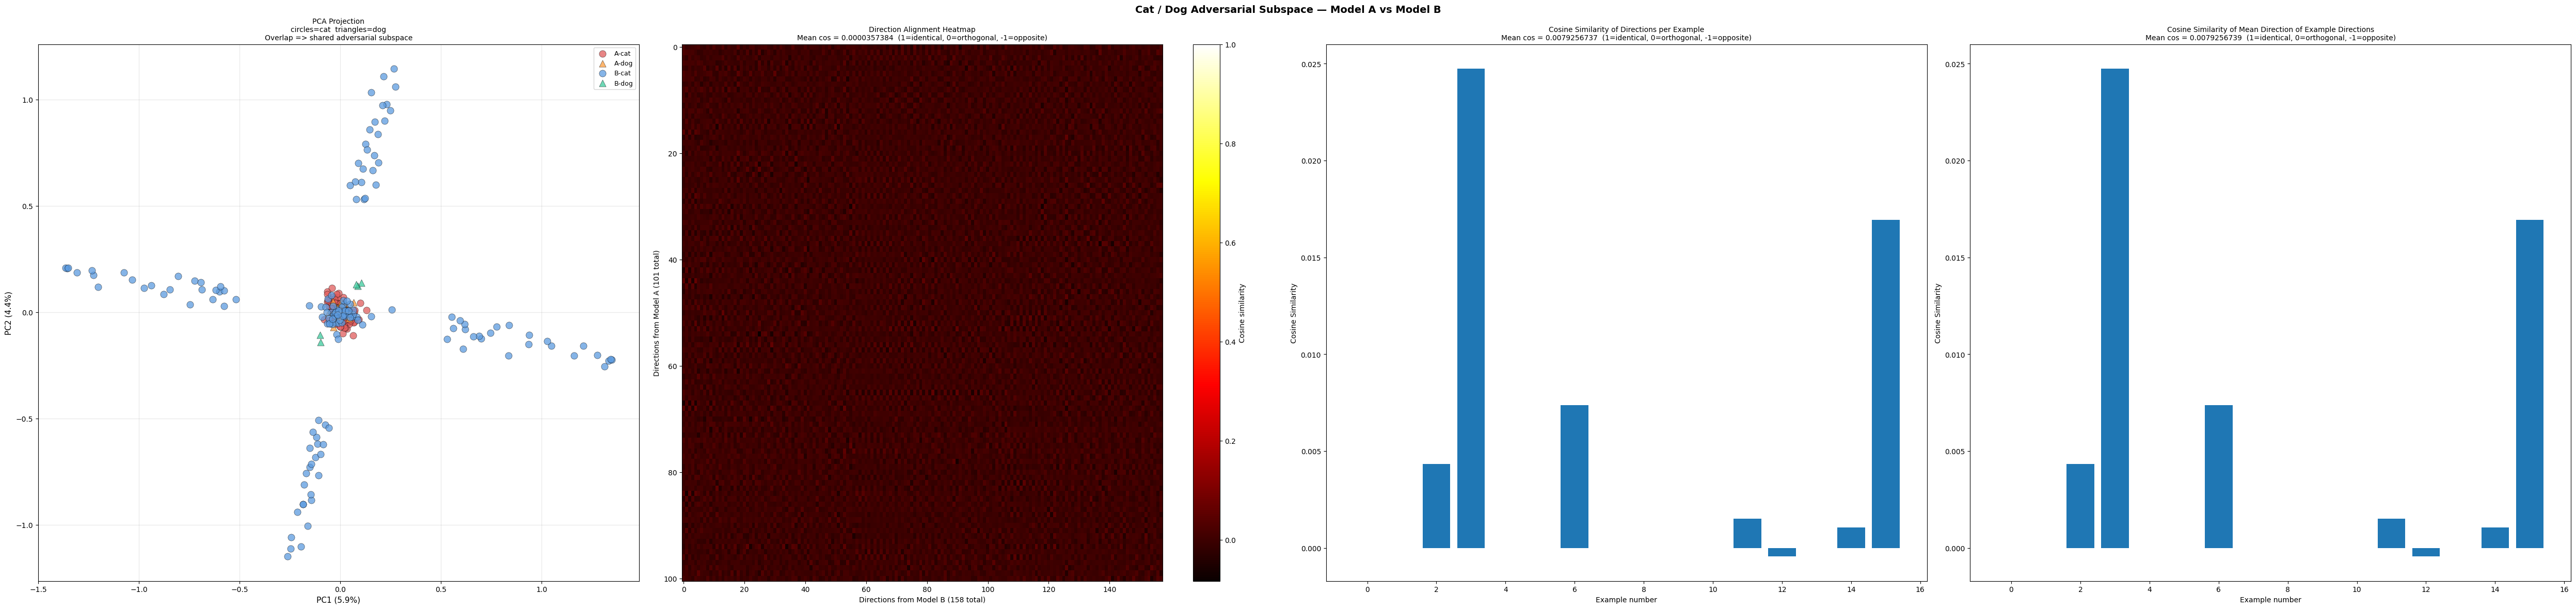


Interpretation:
  Cat/Dog |cos| = 0.000 => LOW    — mostly orthogonal subspaces
  PCA top-2 PCs capture 10.3% of variance


In [54]:
if len(all_dirs_a) + len(all_dirs_b) < 2:
    print("Not enough directions to visualise — enlarge the batch.")
else:
    all_vecs   = np.array(all_dirs_a + all_dirs_b)
    src_labels = ["Model A"] * len(all_dirs_a) + ["Model B"] * len(all_dirs_b)
    cls_labels = labels_a + labels_b

    pca     = PCA(n_components=2)
    vecs_2d = pca.fit_transform(all_vecs)
    ev      = pca.explained_variance_ratio_

    fig, axes = plt.subplots(1, 4, figsize=(50, 12))
    fig.suptitle("Cat / Dog Adversarial Subspace — Model A vs Model B",
                 fontsize=14, fontweight="bold")

    ax = axes[0]
    style_map = {
        ("Model A","cat"): ("o","#E05C5C","A-cat"),
        ("Model A","dog"): ("^","#FF9E3E","A-dog"),
        ("Model B","cat"): ("o","#5C9BE0","B-cat"),
        ("Model B","dog"): ("^","#3ECB9E","B-dog"),
    }
    for (mdl, cls), (mk, col, lbl) in style_map.items():
        idx = [j for j,(s,cc) in enumerate(zip(src_labels, cls_labels))
               if s == mdl and cc == cls]
        if idx:
            pts = vecs_2d[idx]
            ax.scatter(pts[:,0], pts[:,1], marker=mk, c=col, label=lbl,
                       alpha=0.75, edgecolors="k", linewidths=0.4, s=90)
    ax.set_xlabel(f"PC1 ({ev[0]:.1%})", fontsize=11)
    ax.set_ylabel(f"PC2 ({ev[1]:.1%})", fontsize=11)
    ax.set_title("PCA Projection\ncircles=cat  triangles=dog\n"
                 "Overlap => shared adversarial subspace", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    if all_dirs_a and all_dirs_b:
        A   = np.array(all_dirs_a)
        B   = np.array(all_dirs_b)
        A_n = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-8)
        B_n = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-8)
        cos_sim  = A_n @ B_n.T
        mean_cos = float(np.mean(cos_sim))
        im = ax2.imshow(cos_sim, aspect="auto", cmap="hot", vmax=1)
        plt.colorbar(im, ax=ax2, label="Cosine similarity")
        ax2.set_xlabel(f"Directions from Model B ({len(all_dirs_b)} total)", fontsize=10)
        ax2.set_ylabel(f"Directions from Model A ({len(all_dirs_a)} total)", fontsize=10)
        ax2.set_title(f"Direction Alignment Heatmap\n"
                      f"Mean cos = {mean_cos:.10f}  (1=identical, 0=orthogonal, -1=opposite)",
                      fontsize=10)
    else:
        ax2.text(0.5, 0.5, "Too few directions", ha="center", va="center",
                 transform=ax2.transAxes)
        mean_cos = None

    ax3 = axes[2]
    if all_ex_dirs_a and all_ex_dirs_b:
        mean_ex_cos_sims = []
        mean_cos_sims = []
        for A, B in zip(all_ex_dirs_a, all_ex_dirs_b):
            if len(A) == 0 or len(B) == 0:
                mean_ex_cos_sims.append(0)
                mean_cos_sims.append(0)
                continue
            A = np.array(A)
            B = np.array(B)
            A_n = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-8)
            B_n = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-8)

            A_m = A_n.mean(axis=0)
            B_m = B_n.mean(axis=0)

            cos_sim  = A_n @ B_n.T
            mean_cos_sim = A_m @ B_m.T
            mean_cos_sims.append(float(mean_cos_sim))
            mean_ex_cos_sims.append(float(np.mean(cos_sim)))
        
        mean_ex_cos_sims = np.array(mean_ex_cos_sims)
        im = ax3.bar(np.arange(len(mean_ex_cos_sims)), mean_ex_cos_sims)
        ax3.set_xlabel(f"Example number", fontsize=10)
        ax3.set_ylabel(f"Cosine Similarity", fontsize=10)

        ax3.set_title(f"Cosine Similarity of Directions per Example\n"
                    f"Mean cos = {float(np.mean(mean_ex_cos_sims[np.nonzero(mean_ex_cos_sims)] )):.10f}  (1=identical, 0=orthogonal, -1=opposite)",
                    fontsize=10)
    else:
        ax3.text(0.5, 0.5, "Too few directions", ha="center", va="center",
                 transform=ax3.transAxes)
        mean_cos = None

    ax4 = axes[3]
    if all_ex_dirs_a and all_ex_dirs_b:
        mean_cos_sims = np.array(mean_cos_sims)
        im = ax4.bar(np.arange(len(mean_cos_sims)), mean_cos_sims)
        ax4.set_xlabel(f"Example number", fontsize=10)
        ax4.set_ylabel(f"Cosine Similarity", fontsize=10)

        ax4.set_title(f"Cosine Similarity of Mean Direction of Example Directions\n"
                    f"Mean cos = {float(np.mean(mean_cos_sims[np.nonzero(mean_cos_sims)] )):.10f}  (1=identical, 0=orthogonal, -1=opposite)",
                    fontsize=10)
    else:
        ax4.text(0.5, 0.5, "Too few directions", ha="center", va="center",
                 transform=ax4.transAxes)
        mean_cos = None

    plt.tight_layout()
    plt.savefig("gaas_catdog_subspace.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nInterpretation:")
    if mean_cos is not None:
        if   mean_cos > 0.5: level = "HIGH   — strong subspace sharing"
        elif mean_cos > 0.2: level = "MODERATE — partial overlap"
        else:                level = "LOW    — mostly orthogonal subspaces"
        print(f"  Cat/Dog |cos| = {mean_cos:.3f} => {level}")
    print(f"  PCA top-2 PCs capture {sum(ev):.1%} of variance")

##  Decision Boundary Analysis : Cat vs Dog
### GAAS Boundary Gradient Similarity

For each Cat/Dog image we already have the full set of GAAS directions from `gaas_directions_linf()` (Section 5). We use those directions — nothing else — to characterise the decision boundary.

**What this measures:**

For each image and each GAAS direction `d_i` we walk `x + alpha * d_i` until the prediction flips, then read off the gradient at that exact boundary point for both models. The cosine similarity between the two boundary gradients tells us how aligned Model A's and Model B's local decision hyperplanes are — measured *along the GAAS perturbation axis*, not along an independent FGSM axis.

**Per-direction metrics reported:**

- `cos(A,B)` — cosine similarity of the boundary gradients for this GAAS direction
- `alpha_A / alpha_B` — how far along `d_i` each model's boundary is
- `flip_A / flip_B` — what class each model predicts at its boundary
- `inter_dist` — `|alpha_A - alpha_B|`, boundary separation along this direction

**Per-image summary:** mean cosine similarity and mean inter-boundary distance across all GAAS directions for that image.


In [28]:
def gaas_boundary_gradient(model, x, y, gaas_dir, steps=100):
    """Return the gradient at the GAAS boundary crossing point.

    gaas_dir is one direction from gaas_directions_linf().
    We walk x + alpha*gaas_dir until the prediction flips, then
    recompute the forward pass WITH gradient tracking to call .backward().
    (The no_grad line-search and the grad-tracked backward are kept separate
    to avoid the RuntimeError: element 0 does not require grad.)

    Returns (boundary_point, gradient_1d, alpha) or (None, None, None).
    """
    model.eval()
    x_dev = x.clone().detach().unsqueeze(0).to(device)  # (1,C,H,W)
    y_dev = y.clone().detach().unsqueeze(0).to(device)
    d     = gaas_dir.to(device)                         # (1,C,H,W)

    # Step 1: line-search under no_grad to find the crossing alpha
    crossing_alpha = None
    with torch.no_grad():
        for step in range(1, steps + 1):
            alpha  = step / steps
            x_walk = (x_dev + alpha * d).clamp(0, 1)
            if model(x_walk).argmax(1).item() != y_dev.item():
                crossing_alpha = alpha
                break

    if crossing_alpha is None:
        return None, None, None

    # Step 2: rebuild x_bd as a fresh leaf tensor WITH requires_grad=True.
    # Must NOT reuse the tensor from inside no_grad - it has no grad_fn.
    x_bd = (x_dev + crossing_alpha * d).clamp(0, 1).detach().requires_grad_(True)
    loss  = F.cross_entropy(model(x_bd), y_dev)
    model.zero_grad()
    loss.backward()
    grad = x_bd.grad.detach().view(-1)

    return x_bd.detach(), grad, crossing_alpha


# Per-image, per-direction GAAS boundary analysis
print("Computing GAAS boundary gradient similarity ...")
print("(Uses the same gaas_directions_linf() directions as Section 6)")
print()

COL = {"img":5, "cls":4, "dir":4, "cos":10, "aa":8, "fa":10, "ab":8, "fb":10, "id":8}
hdr = (f"{'Img':<{COL['img']}} {'Cls':<{COL['cls']}} {'Dir':<{COL['dir']}}" f" {'cos(A,B)':<{COL['cos']}} {'alphaA':<{COL['aa']}} {'flipA':<{COL['fa']}}" f" {'alphaB':<{COL['ab']}} {'flipB':<{COL['fb']}} {'interD':<{COL['id']}}")
print(hdr)
print("-" * len(hdr))

cos_sims_boundary = []   # kept for Section 11 summary
boundary_records  = []

for i in range(n):
    xi, yi = clean_images[i], clean_labels[i]
    cls    = BINARY_CLASSES.get(yi.item(), CLASSES[yi.item()])

    dirs_a = gaas_directions_linf(model_a, xi, yi, max_dirs=50)
    dirs_b = gaas_directions_linf(model_b, xi, yi, max_dirs=50)

    # Use model A directions as the shared axis; fall back to B if A has none
    all_dirs = dirs_a if dirs_a else dirs_b

    if not all_dirs:
        print(f"{i:<{COL['img']}} {cls:<{COL['cls']}}  -- no GAAS directions --")
        boundary_records.append(
            dict(idx=i, cls=cls, dir_cos=[], alpha_a=[], alpha_b=[],
                 inter=[], flip_a=[], flip_b=[]))
        continue

    rec = dict(idx=i, cls=cls, dir_cos=[], alpha_a=[], alpha_b=[],
               inter=[], flip_a=[], flip_b=[])

    for d_idx, gaas_d in enumerate(all_dirs):
        x_bd_a, g_a, alpha_a = gaas_boundary_gradient(model_a, xi, yi, gaas_d)
        x_bd_b, g_b, alpha_b = gaas_boundary_gradient(model_b, xi, yi, gaas_d)

        flip_a_cls = "--"
        flip_b_cls = "--"
        with torch.no_grad():
            if x_bd_a is not None:
                flip_a_cls = CLASSES[model_a(x_bd_a).argmax(1).item()]
            if x_bd_b is not None:
                flip_b_cls = CLASSES[model_b(x_bd_b).argmax(1).item()]

        a_str = f"{alpha_a:.3f}" if alpha_a is not None else "N/A"
        b_str = f"{alpha_b:.3f}" if alpha_b is not None else "N/A"

        if g_a is None or g_b is None:
            print(f"{i:<{COL['img']}} {cls:<{COL['cls']}} d{d_idx:<{COL['dir']-1}}"
                  f" {'N/A':<{COL['cos']}} {a_str:<{COL['aa']}} {flip_a_cls:<{COL['fa']}}"
                  f" {b_str:<{COL['ab']}} {flip_b_cls:<{COL['fb']}} {'N/A':<{COL['id']}}")
            continue

        cos     = float(F.cosine_similarity(g_a.unsqueeze(0), g_b.unsqueeze(0)).item())
        inter_d = abs(alpha_a - alpha_b)

        rec["dir_cos"].append(cos)
        rec["alpha_a"].append(alpha_a)
        rec["alpha_b"].append(alpha_b)
        rec["inter"].append(inter_d)
        rec["flip_a"].append(flip_a_cls)
        rec["flip_b"].append(flip_b_cls)
        cos_sims_boundary.append(cos)

        print(f"{i:<{COL['img']}} {cls:<{COL['cls']}} d{d_idx:<{COL['dir']-1}}"
              f" {cos:<{COL['cos']}.4f} {a_str:<{COL['aa']}} {flip_a_cls:<{COL['fa']}}"
              f" {b_str:<{COL['ab']}} {flip_b_cls:<{COL['fb']}} {inter_d:<{COL['id']}.4f}")

    boundary_records.append(rec)

    if rec["dir_cos"]:
        mc_i = np.mean(rec["dir_cos"])
        mi_i = np.mean(rec["inter"])
        print(f"  => img {i} ({cls}): mean cos={mc_i:.4f}  mean inter_dist={mi_i:.4f}")
    print()

# Global summary
if cos_sims_boundary:
    mc = np.mean(cos_sims_boundary)
    print("=" * 60)
    print(f"Global mean GAAS boundary cos similarity (A vs B): {mc:.4f}")
    if   mc > 0.7: level = "Very high  -- boundaries nearly co-located"
    elif mc > 0.3: level = "Moderate   -- partially aligned"
    else:          level = "Low        -- boundaries diverge between models"
    print(f"  => {level}")
    print()
    print("Interpretation:")
    print("  cos ~ 1 => both models share the same local decision hyperplane")
    print("             at the GAAS boundary crossing point.")
    print("  cos ~ 0 => boundaries are geometrically orthogonal even though")
    print("             the same GAAS direction crosses both.")
    print("  inter_dist ~ 0 => boundaries equidistant from the clean image.")
else:
    cos_sims_boundary = []
    print("No GAAS boundary gradients computed -- check Section 6 has directions.")


Computing GAAS boundary gradient similarity ...
(Uses the same gaas_directions_linf() directions as Section 6)

Img   Cls  Dir  cos(A,B)   alphaA   flipA      alphaB   flipB      interD  
---------------------------------------------------------------------------
0     dog  d0   N/A        0.170    cat        N/A      --         N/A     

1     cat   -- no GAAS directions --
2     dog  d0   N/A        0.090    bird       N/A      --         N/A     
2     dog  d1   N/A        0.210    cat        N/A      --         N/A     
2     dog  d2   N/A        0.210    bird       N/A      --         N/A     
2     dog  d3   N/A        0.400    cat        N/A      --         N/A     
2     dog  d4   N/A        0.280    bird       N/A      --         N/A     
2     dog  d5   N/A        0.530    cat        N/A      --         N/A     
2     dog  d6   N/A        0.400    bird       N/A      --         N/A     
2     dog  d7   N/A        0.740    cat        N/A      --         N/A     
2     dog  d8 

###  Morphological Feature Trajectory (GAAS Direction)

The trajectory walks the image along a **real GAAS direction** — one of the orthogonal adversarial directions found by `gaas_directions_linf()` in Section 5 — at the same epsilon budget (8/255).

**Direction selection:** the first GAAS direction that flips the prediction to the target class (cat->dog or dog->cat). If none of the GAAS directions go to the exact target, the first direction (any misclassification) is used and flagged.

This is not a targeted attack. The gradient is the standard cross-entropy gradient with respect to the true class, then Gram-Schmidt orthogonalised against previously found directions.

**Panel D fix:** `Standard` and `Engstrom2019` have different penultimate-layer widths (640 vs 2048). Each model's features are projected to 32D independently before joint PCA, so `np.vstack` never sees mismatched dimensions.


In [29]:
def make_feature_hook(model):
    """Attach a forward hook to the penultimate Linear layer.

    Finds the widest nn.Linear whose out_features != 10 (not the classifier
    head).  The hook stores inp[0] — the activation vector entering that
    layer — in store["vec"] after every forward pass.

    Returns (store_dict, hook_handle, feature_dim).
    feature_dim is the size of the stored vector (e.g. 640 or 2048).
    Call handle.remove() when done to avoid memory leaks.
    """
    store   = {}
    linears = [(nm, mod) for nm, mod in model.named_modules()
               if isinstance(mod, nn.Linear)]
    target  = None
    feat_dim = None
    for name, layer in sorted(linears, key=lambda t: -t[1].out_features):
        if layer.out_features != 10:
            target   = layer
            feat_dim = layer.in_features   # inp[0] has this many dims
            break
    if target is None and linears:
        target   = linears[-1][1]
        feat_dim = target.in_features
    if target is None:
        return store, None, 10   # no Linear at all; caller uses softmax fallback

    def _hook(module, inp, out):
        store["vec"] = inp[0].detach().view(inp[0].size(0), -1).cpu()

    handle = target.register_forward_hook(_hook)
    return store, handle, feat_dim


print("make_feature_hook defined (returns feat_dim so callers lock the dimension).")


make_feature_hook defined (returns feat_dim so callers lock the dimension).


In [30]:
def gaas_morphological_trajectory(model, x, y_src, y_tgt,
                                   n_steps=40,
                                   epsilon=EPSILON,
                                   max_dirs=50):
    """Walk along a GAAS adversarial direction from class y_src toward y_tgt.

    The direction is taken from gaas_directions_linf() at the same epsilon
    budget used throughout the notebook -- this is pure GAAS, not a targeted
    attack.

    Direction selection priority:
      1. First GAAS direction that flips the prediction to y_tgt (cat->dog).
      2. First GAAS direction that causes any misclassification (flagged).
      3. Return None if no adversarial direction exists.

    Feature collection fix:
      make_feature_hook now returns feat_dim (the hook layer width).
      A warm-up forward confirms the hook fires.  Every trajectory step uses
      feat_dim-zeros as a fallback instead of softmax (10-dim), so
      np.array(features_traj) is always shape (n_steps+1, feat_dim) --
      never an inhomogeneous object array.
    """
    model.eval()
    x_dev   = x.clone().detach().to(device)
    x_batch = x_dev.unsqueeze(0)                   # (1,C,H,W)

    # Step 1: GAAS directions (same function as Section 6)
    dirs = gaas_directions_linf(
        model, x_dev,
        torch.tensor(y_src, device=device),
        epsilon=epsilon, max_dirs=max_dirs)

    if not dirs:
        return None

    # Step 2: pick the best direction
    chosen_dir   = None
    chosen_idx   = -1
    flips_to_tgt = False

    with torch.no_grad():
        for idx, d in enumerate(dirs):
            if model((x_batch + d).clamp(0, 1)).argmax(1).item() == y_tgt:
                chosen_dir, chosen_idx, flips_to_tgt = d, idx, True
                break

    if chosen_dir is None:                         # no dir goes to y_tgt
        chosen_dir, chosen_idx = dirs[0], 0
        with torch.no_grad():
            any_pred = model((x_batch + chosen_dir).clamp(0, 1)).argmax(1).item()
        print(f"  [note] No GAAS dir flips to {CLASSES[y_tgt]}; "
              f"dir[0] flips to {CLASSES[any_pred]}.")

    # Step 3: set up feature hook and lock the feature dimension
    store, handle, feat_dim = make_feature_hook(model)

    # Warm-up: one forward to confirm the hook fires and feat_dim is correct
    with torch.no_grad():
        _ = model(x_batch)
    if store.get("vec") is not None:
        feat_dim = store["vec"].shape[1]           # use actual observed dim
    # feat_dim is now locked -- every step will produce a vector of this size

    # Step 4: record the trajectory
    images_traj, features_traj, preds_traj = [], [], []
    probs_src_traj, probs_tgt_traj = [], []

    for step in range(n_steps + 1):
        alpha  = step / n_steps
        x_step = (x_batch + alpha * chosen_dir).clamp(0, 1)

        with torch.no_grad():
            logits = model(x_step)

        soft = F.softmax(logits, dim=1).squeeze(0)
        pred = logits.argmax(1).item()

        images_traj.append(x_step.squeeze(0).cpu())
        preds_traj.append(pred)
        probs_src_traj.append(soft[y_src].item())
        probs_tgt_traj.append(soft[y_tgt].item())

        # Feature vector: always feat_dim wide (zeros if hook did not fire)
        if store.get("vec") is not None and store["vec"].shape[1] == feat_dim:
            features_traj.append(store["vec"].squeeze(0).numpy())
        else:
            features_traj.append(np.zeros(feat_dim, dtype=np.float32))

    if handle:
        handle.remove()

    return {
        "images":       images_traj,
        "features":     np.array(features_traj),  # always (n_steps+1, feat_dim)
        "preds":        preds_traj,
        "probs_src":    probs_src_traj,
        "probs_tgt":    probs_tgt_traj,
        "direction":    chosen_dir,
        "dir_index":    chosen_idx,
        "flips_to_tgt": flips_to_tgt,
        "epsilon_used": epsilon,
    }


print("gaas_morphological_trajectory defined.")
print("Features are always shape (n_steps+1, feat_dim) -- vstack-safe.")


gaas_morphological_trajectory defined.
Features are always shape (n_steps+1, feat_dim) -- vstack-safe.


In [31]:
def find_ideal_demo_sample(clean_images, clean_labels,
                           model_primary, model_secondary=None,
                           src_class=CAT_IDX, tgt_class=DOG_IDX,
                           epsilon=EPSILON):
    """Scan the batch for an image where a GAAS direction flips src->tgt.

    Search order:
      Pass 1: src images where a GAAS dir flips directly to tgt.
      Pass 2: tgt images where a GAAS dir flips directly to src.
      Pass 3: src images where ANY GAAS dir exists (any flip target).
      Pass 4: tgt images where ANY GAAS dir exists.

    Only gaas_morphological_trajectory() is called -- no targeted attacks.
    Returns (x, y_src, y_tgt, traj_primary, traj_secondary).
    All values are None if no adversarial image is found in the batch.
    """
    cands     = [i for i in range(len(clean_labels))
                 if clean_labels[i].item() == src_class]
    rev_cands = [i for i in range(len(clean_labels))
                 if clean_labels[i].item() == tgt_class]

    def _try(idx, s, t):
        return gaas_morphological_trajectory(
            model_primary, clean_images[idx],
            y_src=s, y_tgt=t, epsilon=epsilon, max_dirs=50)

    # Pass 1 & 2: need a direction that flips to the exact target class
    for cand_list, s, t in [(cands, src_class, tgt_class),
                            (rev_cands, tgt_class, src_class)]:
        for idx in cand_list:
            tp = _try(idx, s, t)
            if tp is not None and tp["flips_to_tgt"]:
                print(f"  [GAAS->tgt] img {idx}  "
                      f"{CLASSES[s]}->{CLASSES[t]}  "
                      f"dir[{tp['dir_index']}]  eps={tp['epsilon_used']:.4f}")
                ts = None
                if model_secondary is not None:
                    ts = gaas_morphological_trajectory(
                            model_secondary, clean_images[idx],
                            y_src=s, y_tgt=t, epsilon=epsilon, max_dirs=50)
                    st = ("GAAS->tgt" if (ts and ts["flips_to_tgt"])
                          else "GAAS->other" if ts else "no dirs")
                    print(f"  Secondary: {st}")
                return clean_images[idx], s, t, tp, ts

    # Pass 3 & 4: accept any GAAS direction
    for cand_list, s, t in [(cands, src_class, tgt_class),
                            (rev_cands, tgt_class, src_class)]:
        for idx in cand_list:
            tp = _try(idx, s, t)
            if tp is not None:
                actual = CLASSES[tp["preds"][-1]]
                print(f"  [GAAS->other] img {idx}  "
                      f"{CLASSES[s]}->{actual} (wanted {CLASSES[t]})  "
                      f"dir[{tp['dir_index']}]  eps={tp['epsilon_used']:.4f}")
                ts = None
                if model_secondary is not None:
                    ts = gaas_morphological_trajectory(
                            model_secondary, clean_images[idx],
                            y_src=s, y_tgt=t, epsilon=epsilon, max_dirs=50)
                return clean_images[idx], s, t, tp, ts

    print("  No adversarial image found -- increase NUM_SAMPLES.")
    return None, None, None, None, None


print("find_ideal_demo_sample defined (pure GAAS, no targeted attacks).")
print("Running search ...\n")

x_demo, y_src_demo, y_tgt_demo, traj_a_new, traj_b_new = find_ideal_demo_sample(
    clean_images, clean_labels,
    model_primary=model_a,
    model_secondary=model_b,
    src_class=CAT_IDX,
    tgt_class=DOG_IDX,
    epsilon=EPSILON,
)

if x_demo is None:
    print("No demo image found -- increase NUM_SAMPLES and re-run Section 3.")
else:
    print(f"\nDemo: {CLASSES[y_src_demo]} -> {CLASSES[y_tgt_demo]}")
    for lbl, traj in [("Model A", traj_a_new), ("Model B", traj_b_new)]:
        if traj is None:
            print(f"  {lbl}: no adversarial directions found.")
            continue
        flip_step = next((s for s, p in enumerate(traj["preds"])
                          if p != y_src_demo), None)
        arrow = "->" if traj["flips_to_tgt"] else "-X->"
        print(f"  {lbl}: GAAS dir[{traj['dir_index']}]  "
              f"flips at step {flip_step}/40  "
              f"{CLASSES[y_src_demo]} {arrow} {CLASSES[traj['preds'][-1]]}  "
              f"feat_dim={traj['features'].shape[1]}")


find_ideal_demo_sample defined (pure GAAS, no targeted attacks).
Running search ...

  [GAAS->tgt] img 3  cat->dog  dir[0]  eps=0.0314
  [note] No GAAS dir flips to dog; dir[0] flips to deer.
  Secondary: GAAS->other

Demo: cat -> dog
  Model A: GAAS dir[0]  flips at step 6/40  cat -> dog  feat_dim=640
  Model B: GAAS dir[0]  flips at step 29/40  cat -X-> deer  feat_dim=2048


In [32]:
def plot_morphology_figure(traj_a, traj_b,
                           y_src, y_tgt,
                           strip_steps=None,
                           save_path="gaas_morphology_4panel.png"):
    """4-panel GAAS morphological trajectory figure.

    All directions come from gaas_directions_linf() (real GAAS) at the
    same epsilon as Section 6.  No targeted attacks anywhere.

    Panel A (2 rows): Pixel strip along the GAAS direction.
      Green border  = still predicted as source class.
      Red border(*) = flipped to target class.
      Orange border = flipped to a third class (GAAS did not go to target).
    Panel B: |clean - adversarial| perturbation map (hot, x10 scaled).
      Shows exactly which pixels the GAAS gradient perturbs.
    Panel C: P(src) and P(tgt) softmax curves; vertical line = crossover.
    Panel D: Feature-space PCA trajectory.
      Each model projected to PROJ_DIM independently then joint 2D PCA.
      This handles mismatched layer widths (Standard=640, Engstrom=2048)
      without vstack errors because features are now always (n_steps+1, feat_dim).
    """
    src_name = CLASSES[y_src]
    tgt_name = CLASSES[y_tgt]
    primary  = traj_a if traj_a is not None else traj_b

    if primary is None:
        print("No trajectory data to plot.")
        return

    n_steps = len(primary["images"]) - 1

    if strip_steps is None:
        strip_steps = [int(round(n_steps * k / 5)) for k in range(6)]
        strip_steps = sorted(set(strip_steps))
    n_strip = len(strip_steps)

    fig = plt.figure(figsize=(max(14, 2.5 * n_strip), 24))

    dir_parts = []
    for lbl, traj in [("A", traj_a), ("B", traj_b)]:
        if traj:
            arrow = "->" if traj["flips_to_tgt"] else "-X->"
            dir_parts.append(
                f"M{lbl}: GAAS dir[{traj['dir_index']}] "
                f"{src_name}{arrow}{CLASSES[traj['preds'][-1]]}")
    dir_info = "   |   ".join(dir_parts)

    fig.suptitle(
        f"GAAS Morphological Trajectory: "
        f"{src_name.upper()} -> {tgt_name.upper()}\n"
        f"Direction: gaas_directions_linf()  eps={primary['epsilon_used']:.4f}\n"
        f"{dir_info}",
        fontsize=12, fontweight="bold", y=1.005)

    outer = gridspec.GridSpec(4, 1, figure=fig, hspace=0.55,
                              height_ratios=[1, 1, 1.3, 1.5])

    # Panel A: pixel morphing strips
    def _draw_strip(traj, row_label, slot):
        inner = gridspec.GridSpecFromSubplotSpec(
            1, n_strip, subplot_spec=slot, wspace=0.06)
        for j, step in enumerate(strip_steps):
            ax = fig.add_subplot(inner[0, j])
            if traj is None or step >= len(traj["images"]):
                ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                        transform=ax.transAxes, fontsize=9, color="#888")
                ax.axis("off"); continue
            img_np  = traj["images"][step].permute(1, 2, 0).numpy().clip(0, 1)
            pred    = traj["preds"][step]
            is_src  = (pred == y_src)
            is_tgt  = (pred == y_tgt)
            conf_s  = traj["probs_src"][step]
            conf_t  = traj["probs_tgt"][step]
            border  = "#27AE60" if is_src else "#C0392B" if is_tgt else "#E67E22"
            ax.imshow(img_np, interpolation="nearest"); ax.axis("off")
            for sp in ax.spines.values():
                sp.set_visible(True); sp.set_edgecolor(border); sp.set_linewidth(3)
            flag = "(*)" if is_tgt else "(x)" if not is_src else ""
            ax.set_title(
                f"Step {step}\n{CLASSES[pred]} {flag}\n"
                f"P(cat)={conf_s:.0%} P(dog)={conf_t:.0%}",
                fontsize=6.5, color=border, pad=2)
        ax0 = fig.add_subplot(inner[0, 0])
        ax0.set_ylabel(row_label, fontsize=9, rotation=90, labelpad=8)
        ax0.axis("off")

    _draw_strip(traj_a, "Model A\n(Standard)", outer[0])
    _draw_strip(traj_b, "Model B\n(Engstrom)",  outer[1])

    # Panel B + C (middle row)
    mid  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[2], wspace=0.40)
    ax_b = fig.add_subplot(mid[0, 0])

    clean_np = primary["images"][0].permute(1, 2, 0).numpy().clip(0, 1)
    adv_np   = primary["images"][-1].permute(1, 2, 0).numpy().clip(0, 1)
    diff_vis = np.clip(np.abs(adv_np - clean_np).mean(axis=2) * 10, 0, 1)
    im = ax_b.imshow(diff_vis, cmap="hot", vmin=0, vmax=1, interpolation="nearest")
    plt.colorbar(im, ax=ax_b, fraction=0.046, pad=0.04, label="|Pixel delta| x10")
    thr = np.percentile(diff_vis, 85)
    ax_b.contour(diff_vis, levels=[thr], colors=["cyan"], linewidths=0.9, alpha=0.8)
    ax_b.axis("off")
    ax_b.set_title(
        "Panel B: GAAS Perturbation Map\n"
        "Hot = pixels most perturbed by the GAAS gradient\n"
        "Cyan = top-15% perturbed region", fontsize=9)
    ins_c = ax_b.inset_axes([0.02, -0.30, 0.44, 0.26])
    ins_a = ax_b.inset_axes([0.54, -0.30, 0.44, 0.26])
    ins_c.imshow(clean_np, interpolation="nearest")
    ins_c.set_title("Clean", fontsize=7); ins_c.axis("off")
    ins_a.imshow(adv_np, interpolation="nearest")
    ins_a.set_title("Adversarial", fontsize=7); ins_a.axis("off")

    ax_c  = fig.add_subplot(mid[0, 1])
    pal   = {"A": ("#E05C5C","#5C9BE0"), "B": ("#FF9E3E","#3ECB9E")}
    any_c = False
    for lbl, traj in [("A", traj_a), ("B", traj_b)]:
        if traj is None: continue
        any_c  = True
        xs     = list(range(len(traj["probs_src"])))
        cs, ct = pal[lbl]
        ax_c.plot(xs, traj["probs_src"], color=cs, lw=2.0, linestyle="-",
                  label=f"M{lbl} P({src_name})")
        ax_c.plot(xs, traj["probs_tgt"], color=ct, lw=2.0, linestyle="--",
                  label=f"M{lbl} P({tgt_name})")
        for s in range(1, len(xs)):
            if traj["probs_src"][s] <= traj["probs_tgt"][s]:
                ax_c.axvline(s, color=cs, linestyle=":", lw=1.2, alpha=0.75)
                voff = 0.60 if lbl == "A" else 0.35
                ax_c.annotate(
                    f"M{lbl} boundary\nstep {s}",
                    xy=(s, 0.5), xytext=(s + 0.8, voff),
                    fontsize=7.5, color=cs,
                    arrowprops=dict(arrowstyle="->", color=cs, lw=0.9))
                break
    if any_c:
        ax_c.axhline(0.5, color="#999", linestyle="--", lw=0.9, alpha=0.7)
        ax_c.set_xlim(0, n_steps); ax_c.set_ylim(-0.03, 1.06)
        ax_c.set_xlabel("Trajectory step along GAAS direction", fontsize=9)
        ax_c.set_ylabel("Softmax probability", fontsize=9)
        ax_c.set_title(
            f"Panel C: Probability Cross-Over (GAAS direction)\n"
            f"Solid = P({src_name})  Dashed = P({tgt_name})\n"
            f"Vertical line = decision boundary crossing", fontsize=9)
        ax_c.legend(fontsize=7.5, loc="center right")
        ax_c.grid(True, alpha=0.3)
    else:
        ax_c.text(0.5, 0.5, "No trajectory data", ha="center", va="center",
                  transform=ax_c.transAxes); ax_c.axis("off")

    # Panel D: feature-space PCA
    ax_d     = fig.add_subplot(outer[3])
    trajs_ok = [(lbl, t) for lbl, t in [("Model A", traj_a), ("Model B", traj_b)]
                if t is not None]

    if not trajs_ok:
        ax_d.text(0.5, 0.5, "No feature data", ha="center", va="center",
                  transform=ax_d.transAxes); ax_d.axis("off")
    else:
        # Validate shapes before projecting
        shape_ok = all(
            t["features"].ndim == 2
            for _, t in trajs_ok
        )
        if not shape_ok:
            ax_d.text(0.5, 0.5,
                      "Feature array has wrong shape\n"
                      "(inhomogeneous dims from hook).\n"
                      "Re-run find_ideal_demo_sample.",
                      ha="center", va="center", transform=ax_d.transAxes,
                      fontsize=9); ax_d.axis("off")
        else:
            # Each model may have a different feat_dim (e.g. 640 vs 2048).
            # Project each independently to PROJ_DIM, then joint PCA to 2D.
            PROJ_DIM = 32

            projected = []
            for lbl, traj in trajs_ok:
                feats = traj["features"]             # guaranteed (n_steps+1, feat_dim)
                k     = min(PROJ_DIM, feats.shape[1], feats.shape[0] - 1)
                k     = max(k, 1)
                pca_i   = PCA(n_components=k)
                reduced = pca_i.fit_transform(feats) # (n_steps+1, k)
                if k < PROJ_DIM:
                    pad     = np.zeros((reduced.shape[0], PROJ_DIM - k))
                    reduced = np.hstack([reduced, pad])
                projected.append((lbl, traj, reduced))

            # Now every reduced array is (n_steps+1, PROJ_DIM) -- safe to vstack
            all_proj  = np.vstack([r for _, _, r in projected])
            n_comp    = min(2, all_proj.shape[0], all_proj.shape[1])
            pca_j     = PCA(n_components=n_comp)
            all_2d    = pca_j.fit_transform(all_proj)
            ev        = pca_j.explained_variance_ratio_

            cpairs = [("#E05C5C","#5C9BE0"), ("#FF9E3E","#3ECB9E")]
            offset = 0

            for (lbl, traj, _), (csrc, ctgt) in zip(projected, cpairs):
                n_t   = len(traj["features"])
                pts   = all_2d[offset: offset + n_t]
                preds = traj["preds"]
                ys    = pts[:, 1] if n_comp == 2 else np.zeros(n_t)

                ax_d.plot(pts[:, 0], ys, color=csrc, lw=1.5, alpha=0.45, zorder=1)

                pt_cols = [csrc if p == y_src
                           else ctgt if p == y_tgt
                           else "#E67E22" for p in preds]
                ax_d.scatter(pts[:, 0], ys, c=pt_cols,
                             edgecolors="white", linewidths=0.4, s=60, zorder=3)

                if n_t > 1:
                    ax_d.annotate("", xy=(pts[-1, 0], ys[-1]),
                                  xytext=(pts[0, 0], ys[0]),
                                  arrowprops=dict(arrowstyle="-|>", color=csrc,
                                                 lw=2.0, mutation_scale=18),
                                  zorder=4)

                ax_d.text(pts[0, 0], ys[0],
                          f"  {lbl}\n  {src_name} (start)",
                          fontsize=7.5, color=csrc, va="center")
                end_col = ctgt if traj["flips_to_tgt"] else "#E67E22"
                ax_d.text(pts[-1, 0], ys[-1],
                          f"  {lbl}\n  {CLASSES[preds[-1]]} (end)",
                          fontsize=7.5, color=end_col, va="center")

                for s_i in range(1, n_t):
                    if preds[s_i] != y_src:
                        star_col = "gold" if traj["flips_to_tgt"] else "#E67E22"
                        ax_d.scatter([pts[s_i, 0]], [ys[s_i]], marker="*",
                                     s=220, color=star_col, edgecolors="k",
                                     lw=0.8, zorder=5, label=f"{lbl} boundary")
                        break

                offset += n_t

            # Approximate decision boundary from primary trajectory
            _, t0, _ = projected[0]
            n_t0     = len(t0["features"])
            pts0     = all_2d[:n_t0]
            ys0      = pts0[:, 1] if n_comp == 2 else np.zeros(n_t0)
            preds0   = t0["preds"]
            csrc0, ctgt0 = cpairs[0]
            for s_i in range(1, n_t0):
                if preds0[s_i] != y_src:
                    bd_x = (pts0[s_i - 1, 0] + pts0[s_i, 0]) / 2
                    ax_d.axvline(bd_x, color="gold", linestyle="--",
                                 lw=1.5, alpha=0.9, label="Approx. boundary (M A)")
                    xlim = ax_d.get_xlim()
                    lo = xlim[0] if xlim[0] != xlim[1] else bd_x - 1
                    hi = xlim[1] if xlim[0] != xlim[1] else bd_x + 1
                    ax_d.axvspan(lo, bd_x, color=csrc0, alpha=0.05)
                    ax_d.axvspan(bd_x, hi, color=ctgt0, alpha=0.05)
                    break

            ax_d.set_xlabel(f"PC1 ({ev[0]:.1%})", fontsize=10)
            ax_d.set_ylabel(
                f"PC2 ({ev[1]:.1%})" if n_comp == 2 else "PC2 (N/A)", fontsize=10)
            ax_d.set_title(
                f"Panel D: Feature-Space PCA Trajectory (GAAS direction)\n"
                f"Per-model PCA -> {PROJ_DIM}D, then joint 2D PCA\n"
                f"src colour = {src_name}  |  tgt colour = {tgt_name}  |  "
                f"orange = other flip  |  star = boundary crossing",
                fontsize=10)
            ax_d.legend(fontsize=8, loc="best")
            ax_d.grid(True, alpha=0.3)

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {save_path}")


print("plot_morphology_figure defined.")
print("Panel D uses per-model PCA to handle mismatched feature dims.")


plot_morphology_figure defined.
Panel D uses per-model PCA to handle mismatched feature dims.


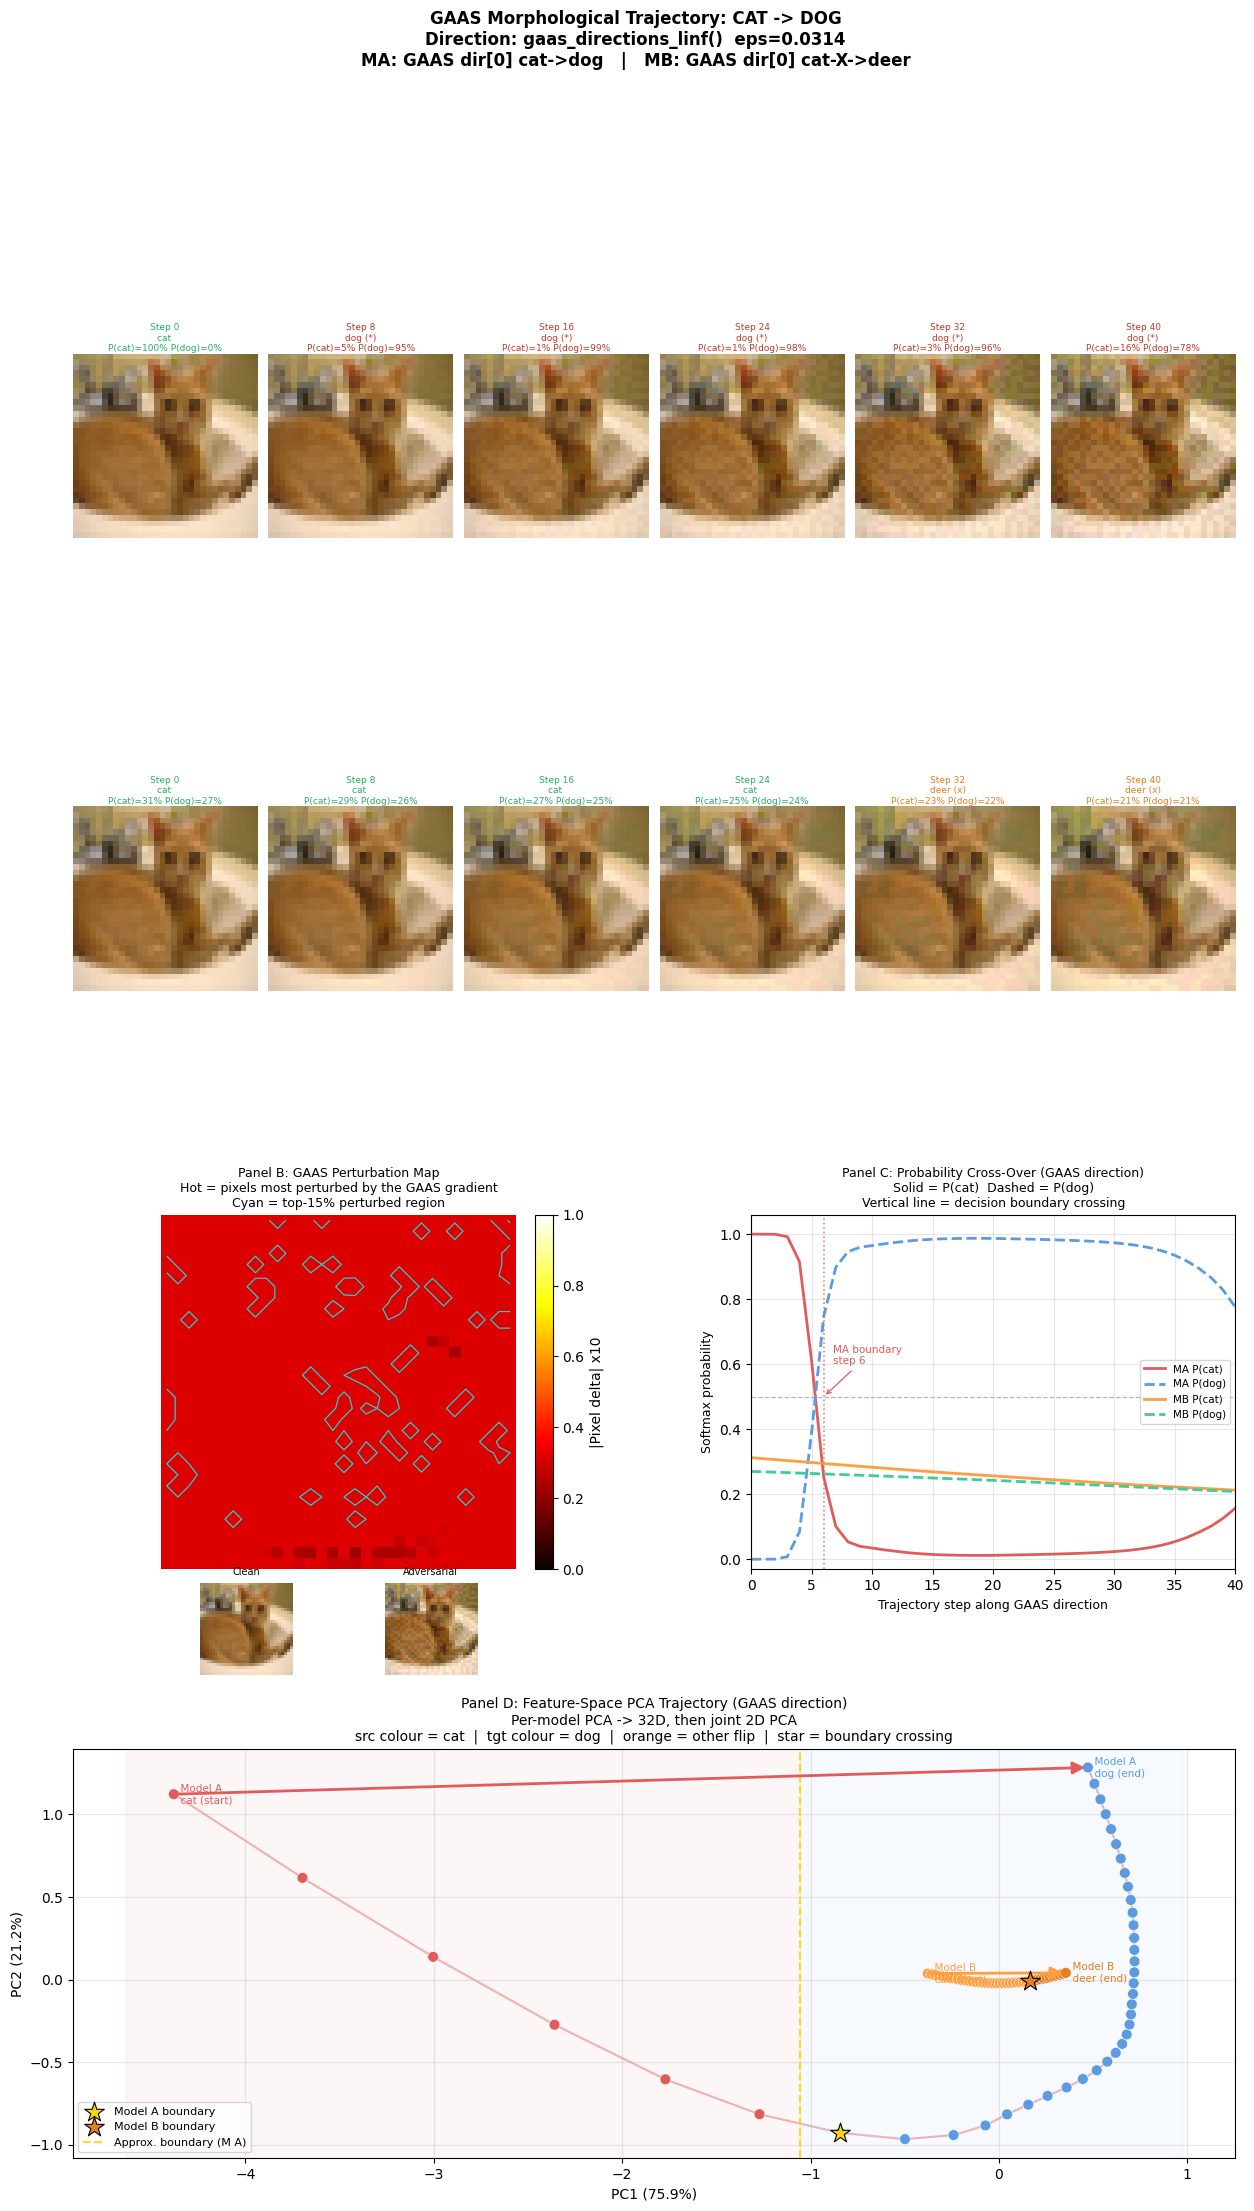

Saved to gaas_morphology_4panel.png


In [33]:
if x_demo is not None:
    plot_morphology_figure(
        traj_a_new, traj_b_new,
        y_src=y_src_demo,
        y_tgt=y_tgt_demo,
        strip_steps=None,
        save_path="gaas_morphology_4panel.png",
    )
else:
    print("No demo image found — increase NUM_SAMPLES and re-run Section 3.")

### Summary

Flipping to a third class is **not a bug** - it is the correct behaviour of GAAS on a 10-class model. The binary cat/dog framing only restricts *which input images* we feed to the algorithm. The output space of the model remains 10-dimensional, and GAAS honestly reflects that geometry.
